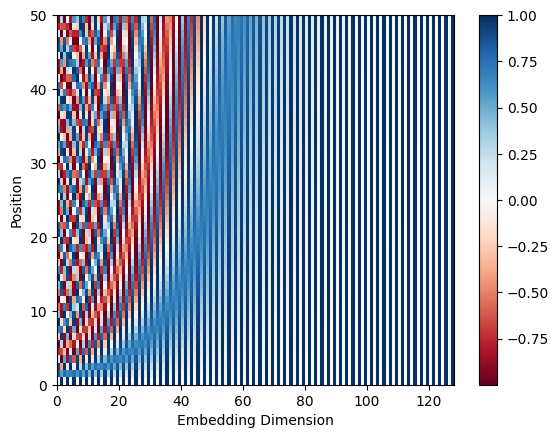

In [1]:
# 위치 인코딩 (단어의?)

import math
import torch
from torch import nn
import matplotlib.pyplot as plt

class PositionalEncoding(nn.Module):
    def __init__(self,
                 d_model,
                 max_len,
                 dropout = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p = dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)

encoding = PositionalEncoding(d_model = 128, max_len = 50)

plt.pcolormesh(encoding.pe.numpy().squeeze(), cmap = "RdBu")
plt.xlabel("Embedding Dimension")
plt.xlim((0, 128))
plt.ylabel("Position")
plt.colorbar()
plt.show()

In [2]:
# Transformer 를 가지고 번역
# 독어를 영어로 만드는걸 해봄 / 독 > 영 > 독 ?

import torch
from torchtext.datasets import Multi30k # 활용해서 builb_vocab
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


In [3]:
SRC_LANG = "de"
TGT_LANG = "en"

UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
special_symbols = ["<unk>", "<pad>", "<bos>", "<eos>"]

token_transform = {SRC_LANG : get_tokenizer("spacy", language = "de_core_news_sm"),
                   TGT_LANG : get_tokenizer("spacy", language = "en_core_web_sm")}

def generate_tokens(text_iter, language):
    language_index = {SRC_LANG: 0, TGT_LANG: 1}

    for text in text_iter:
        yield token_transform[language](text[language_index[language]])

print(token_transform)

{'de': functools.partial(<function _spacy_tokens at 0x000001718D18C2C0>, tokenizer=<spacy.tokenizer.Tokenizer object at 0x000001718895DD80>), 'en': functools.partial(<function _spacy_tokens at 0x000001718D18C2C0>, tokenizer=<spacy.tokenizer.Tokenizer object at 0x000001718895E4D0>)}


In [4]:
print(token_transform["de"]("Zwei junge weiße Männer sind im Freien."))
print(token_transform["en"]("Two young, White males are outside."))

['Zwei', 'junge', 'weiße', 'Männer', 'sind', 'im', 'Freien', '.']
['Two', 'young', ',', 'White', 'males', 'are', 'outside', '.']


In [5]:
# 단어 사전 생성
vocab_transform = {}
for language in [SRC_LANG, TGT_LANG]:
    train_iter = Multi30k(split = "train",
                          language_pair = (SRC_LANG, TGT_LANG))
    vocab_transform[language] = build_vocab_from_iterator(generate_tokens(train_iter, language),
                                                          min_freq = 1,
                                                          specials = special_symbols,
                                                          special_first = True)

for language in [SRC_LANG, TGT_LANG]:
    vocab_transform[language].set_default_index(UNK_IDX)

print(vocab_transform)

{'de': <torchtext_compat.vocab.Vocab object at 0x0000017194473910>, 'en': <torchtext_compat.vocab.Vocab object at 0x000001719891F850>}


In [6]:
# 모델 정의

import math
import torch
from torch import nn

class PositionalEncoding(nn.Module):
    def __init__(self,
                 d_model,
                 max_len,
                 dropout = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(p = dropout)
        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[: x.size(0)]
        return self.dropout(x)

In [7]:
# 단어를 숫자 벡터로

class TokenEmbedding(nn.Module):
    def __init__(self, vocab_size, emb_size):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_size)
        self.emb_size = emb_size

    def forward(self, tokens):
        return self.embedding(tokens.long()) * math.sqrt(self.emb_size)